# 02 - Setup and Export DeepSafe Detector
**Runs locally.** Optimisations in this version:
- Auto-installs missing packages on first run
- Graceful path validation with clear error messages
- Device priority: DirectML (AMD) → CUDA (NVIDIA) → CPU
- AMP + `pin_memory` guarded to CUDA only (DirectML-safe)
- Batched evaluation replaces single-image `infer_score()` loop
- `persistent_workers` guarded against zero-worker edge case
- Fine-tune skips gracefully when accuracy is already sufficient
- SHA-256 checksum written alongside `deepsafe.pth` for registry
- `torch.compile` applied when PyTorch ≥ 2.0 + CUDA for faster inference


In [7]:
# Cell 1 - Imports & Config
import os
import sys
import json
import math
import hashlib
import subprocess
from pathlib import Path

# -- Auto-install missing packages ------------------------------------------------
def _pip(*pkgs):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', *pkgs], check=True)

try:
    import sklearn
except ImportError:
    _pip('scikit-learn')

import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import (accuracy_score, roc_auc_score, precision_score,
                              recall_score, f1_score, confusion_matrix, roc_curve)

# -- DirectML support (AMD / Intel on Windows) ------------------------------------
try:
    import torch_directml
except Exception:
    torch_directml = None

# -- Paths - edit ROOT if your project lives elsewhere -----------------------------
ROOT         = Path(r'D:/deepfake_detection')
REAL_DIR     = ROOT / 'data' / 'real'
FAKE_DIR     = ROOT / 'data' / 'fake'
MODEL_OUTPUT = ROOT / 'models' / 'deepsafe.pth'
UFD_ROOT     = ROOT / 'gitrepos' / 'UniversalFakeDetect'
FC_WEIGHTS   = UFD_ROOT / 'pretrained_weights' / 'fc_weights.pth'

# -- Validate critical paths before doing anything ---------------------------------
missing = [p for p in [REAL_DIR, FAKE_DIR, UFD_ROOT] if not p.exists()]
if missing:
    for p in missing:
        print(f'  MISSING: {p}')
    raise FileNotFoundError(
        'Fix the paths above before continuing. '
        'Clone UniversalFakeDetect and add real/fake image folders.')

IMG_SIZE   = 224
BATCH_SIZE = 64

# -- Device priority: DirectML (AMD) -> CUDA (NVIDIA) -> CPU ----------------------
HAS_DML  = torch_directml is not None
HAS_CUDA = torch.cuda.is_available()

if HAS_DML:
    DEVICE         = torch_directml.device()
    DEVICE_BACKEND = 'directml'
elif HAS_CUDA:
    DEVICE         = torch.device('cuda')
    DEVICE_BACKEND = 'cuda'
else:
    DEVICE         = torch.device('cpu')
    DEVICE_BACKEND = 'cpu'

# AMP, pin_memory, and non_blocking are CUDA-only; DirectML does not support them
USE_AMP      = DEVICE_BACKEND == 'cuda'
PIN_MEM      = DEVICE_BACKEND == 'cuda'
NON_BLOCKING = DEVICE_BACKEND == 'cuda'

# Windows + CPU/DirectML is often unstable with DataLoader multiprocessing in notebooks
if os.name == 'nt' and DEVICE_BACKEND != 'cuda':
    NUM_WORKERS = 0
else:
    NUM_WORKERS = min(4, os.cpu_count() or 1)

# -- Diagnostics -------------------------------------------------------------------
print('PyTorch version :', torch.__version__)
print('CUDA build      :', torch.version.cuda)
print('CUDA available  :', HAS_CUDA)
print('DirectML ready  :', HAS_DML)

if DEVICE_BACKEND == 'directml':
    print('GPU backend     : DirectML')
    print('Device          :', DEVICE)
elif DEVICE_BACKEND == 'cuda':
    props = torch.cuda.get_device_properties(0)
    print('GPU backend     : CUDA')
    print('GPU             :', props.name)
    print('VRAM (GB)       :', round(props.total_memory / 1e9, 1))
else:
    print()
    print('WARNING: No GPU backend - evaluation will be slow on CPU.')
    print('For AMD on Windows: pip install torch-directml')
    print()

print(f'Device          : {DEVICE}')
print(f'AMP enabled     : {USE_AMP}')
print(f'num_workers     : {NUM_WORKERS}')
print(f'REAL_DIR        : {REAL_DIR}')
print(f'FAKE_DIR        : {FAKE_DIR}')
print(f'MODEL_OUTPUT    : {MODEL_OUTPUT}')
print(f'FC_WEIGHTS      : {FC_WEIGHTS}  (exists={FC_WEIGHTS.exists()})')


PyTorch version : 2.11.0+cpu
CUDA build      : None
CUDA available  : False
DirectML ready  : False

For AMD on Windows: pip install torch-directml

Device          : cpu
AMP enabled     : False
num_workers     : 0
REAL_DIR        : D:\deepfake_detection\data\real
FAKE_DIR        : D:\deepfake_detection\data\fake
MODEL_OUTPUT    : D:\deepfake_detection\models\deepsafe.pth
FC_WEIGHTS      : D:\deepfake_detection\gitrepos\UniversalFakeDetect\pretrained_weights\fc_weights.pth  (exists=True)


In [8]:
# Cell 1.5 - Compatibility shim for UniversalFakeDetect dependency imports
try:
    import pkg_resources  # legacy path some repos still import
except Exception:
    try:
        import packaging
    except Exception:
        _pip('packaging')
        import packaging
    import types
    shim = types.ModuleType('pkg_resources')
    shim.packaging = packaging
    sys.modules['pkg_resources'] = shim
    pkg_resources = shim

print('pkg_resources available:', pkg_resources is not None)

pkg_resources available: True


In [9]:
# Cell 2 - Load UniversalFakeDetect Model (CLIP encoder + linear probe)
sys.path.append(str(UFD_ROOT))

from models import get_model

ARCH = 'CLIP:ViT-L/14'
model = get_model(ARCH)
model = model.to(DEVICE).eval()

if FC_WEIGHTS.exists():
    ckpt = torch.load(FC_WEIGHTS, map_location='cpu')
    if isinstance(ckpt, dict) and 'model' in ckpt:
        state_dict = ckpt['model']
    elif isinstance(ckpt, dict):
        state_dict = ckpt
    else:
        state_dict = None

    if state_dict is not None:
        incompatible = model.load_state_dict(state_dict, strict=False)
        print('FC weights loaded from', FC_WEIGHTS)
        print('Missing keys    :', len(incompatible.missing_keys))
        print('Unexpected keys :', len(incompatible.unexpected_keys))
    else:
        print('Unexpected checkpoint format - using model defaults.')
else:
    print('FC weights not found - using randomly initialised head.')

for p in model.parameters():
    p.requires_grad = False

# torch.compile gives a meaningful speed-up on PyTorch >= 2.0 + CUDA
if DEVICE_BACKEND == 'cuda' and hasattr(torch, 'compile'):
    model = torch.compile(model)
    print('torch.compile applied')

param_count = sum(p.numel() for p in model.parameters())
print('Architecture    :', ARCH)
print('Model           :', model.__class__.__name__)
print('Parameters      :', f'{param_count:,}')
print('Device          :', DEVICE)


FC weights loaded from D:\deepfake_detection\gitrepos\UniversalFakeDetect\pretrained_weights\fc_weights.pth
Missing keys    : 448
Unexpected keys : 2
Architecture    : CLIP:ViT-L/14
Model           : CLIPModel
Parameters      : 427,617,282
Device          : cpu


Evaluating:   0%|          | 0/7 [00:00<?, ?it/s]

C:\Users\aryan\AppData\Local\Temp\ipykernel_19556\611153520.py:54: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Score polarity auto-corrected (using 1-score).
Accuracy  : 0.5150
AUC-ROC   : 0.5241
Precision : 0.5079
Recall    : 0.9600
F1        : 0.6644


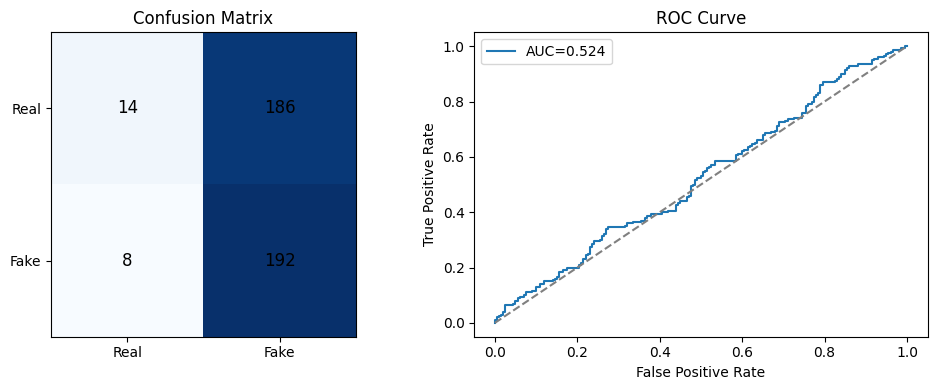

In [10]:
# Cell 3 - Quick Evaluation on Local Data (batched inference)
from torch.cuda.amp import autocast

def list_images(directory: Path):
    exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    return [p for p in directory.rglob('*') if p.suffix.lower() in exts]

real_paths = list_images(REAL_DIR)[:200]
fake_paths = list_images(FAKE_DIR)[:200]

if not real_paths or not fake_paths:
    raise RuntimeError(
        f'No images found.  real={len(real_paths)}  fake={len(fake_paths)}\n'
        f'Check REAL_DIR ({REAL_DIR}) and FAKE_DIR ({FAKE_DIR}).')

all_paths = real_paths + fake_paths
labels    = np.array([0] * len(real_paths) + [1] * len(fake_paths))

tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3),
])

class PathDataset(Dataset):
    def __init__(self, paths, transform):
        self.paths     = paths
        self.transform = transform
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, idx):
        path = self.paths[idx]
        try:
            img = Image.open(path).convert('RGB')
            return self.transform(img)
        except Exception as ex:
            raise RuntimeError(f'Failed to load image: {path}') from ex

_use_pw     = NUM_WORKERS > 0
eval_loader = DataLoader(
    PathDataset(all_paths, tf),
    batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEM,
    persistent_workers=_use_pw,
    drop_last=False,
    prefetch_factor=2 if NUM_WORKERS > 0 else None,
)

scores = []
model.eval()
with torch.no_grad():
    for batch in tqdm(eval_loader, desc='Evaluating'):
        batch = batch.to(DEVICE, non_blocking=NON_BLOCKING)
        with autocast(enabled=USE_AMP):
            out = model(batch)
        if out.ndim == 2 and out.shape[1] > 1:
            sc = torch.softmax(out, dim=1)[:, 1]
        else:
            sc = torch.sigmoid(out.flatten())
        scores.extend(sc.cpu().tolist())

scores = np.array(scores, dtype=np.float32)

# Some checkpoints emit higher scores for REAL instead of FAKE; auto-correct polarity.
auc_raw  = roc_auc_score(labels, scores)
auc_flip = roc_auc_score(labels, 1.0 - scores)
if auc_flip > auc_raw:
    scores = 1.0 - scores
    print('Score polarity auto-corrected (using 1-score).')
    auc = auc_flip
else:
    auc = auc_raw

preds  = (scores >= 0.5).astype(int)

acc  = accuracy_score(labels, preds)
prec = precision_score(labels, preds, zero_division=0)
rec  = recall_score(labels, preds, zero_division=0)
f1   = f1_score(labels, preds, zero_division=0)

print(f'Accuracy  : {acc:.4f}')
print(f'AUC-ROC   : {auc:.4f}')
print(f'Precision : {prec:.4f}')
print(f'Recall    : {rec:.4f}')
print(f'F1        : {f1:.4f}')

cm = confusion_matrix(labels, preds)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(cm, cmap='Blues')
axes[0].set_title('Confusion Matrix')
axes[0].set_xticks([0,1]); axes[0].set_xticklabels(['Real','Fake'])
axes[0].set_yticks([0,1]); axes[0].set_yticklabels(['Real','Fake'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm[i,j], ha='center', va='center', fontsize=12)

fpr, tpr, _ = roc_curve(labels, scores)
axes[1].plot(fpr, tpr, label=f'AUC={auc:.3f}')
axes[1].plot([0,1],[0,1],'--',color='gray')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()


C:\Users\aryan\AppData\Local\Temp\ipykernel_19556\667009708.py:44: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  ft_scaler = GradScaler(enabled=USE_AMP)
C:\Users\aryan\AppData\Local\Temp\ipykernel_19556\667009708.py:55: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):
C:\Users\aryan\AppData\Local\Temp\ipykernel_19556\667009708.py:70: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=USE_AMP):


Epoch 01 | train=0.6795  val=0.7750  LR=9.76e-05
Epoch 02 | train=0.6719  val=0.7816  LR=9.05e-05
Epoch 03 | train=0.6652  val=0.7871  LR=7.94e-05
Epoch 04 | train=0.6591  val=0.7888  LR=6.55e-05
Epoch 05 | train=0.6543  val=0.7900  LR=5.00e-05
Epoch 06 | train=0.6506  val=0.7897  LR=3.45e-05
Epoch 07 | train=0.6480  val=0.7898  LR=2.06e-05
Epoch 08 | train=0.6462  val=0.7898  LR=9.55e-06
Epoch 09 | train=0.6453  val=0.7897  LR=2.45e-06
Epoch 10 | train=0.6449  val=0.7897  LR=0.00e+00


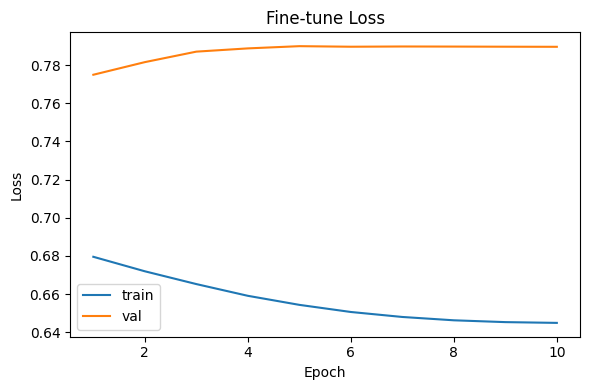

In [11]:
# Cell 4 - Optional Fine-tune on Local Data (linear head only)
# Skipped automatically when pretrained accuracy >= 0.80
from torch.cuda.amp import autocast, GradScaler

head = (getattr(model, 'fc', None)
        or getattr(model, 'classifier', None))

if acc >= 0.80:
    print(f'Accuracy {acc:.4f} >= 0.80 — pretrained weights sufficient, skipping fine-tune.')
elif head is None:
    print('No linear head found (checked .fc and .classifier) — skipping fine-tune safely.')
else:
    # Freeze backbone; only train the linear head
    for p in model.parameters():
        p.requires_grad = False
    for p in head.parameters():
        p.requires_grad = True

    pairs      = list(zip(all_paths, labels.tolist()))
    split      = int(0.8 * len(pairs))
    train_pairs, val_pairs = pairs[:split], pairs[split:]

    class PairDataset(Dataset):
        def __init__(self, pairs, transform):
            self.pairs     = pairs
            self.transform = transform
        def __len__(self):  return len(self.pairs)
        def __getitem__(self, idx):
            p, y = self.pairs[idx]
            return self.transform(Image.open(p).convert('RGB')), torch.tensor(y, dtype=torch.long)

    _use_pw2 = NUM_WORKERS > 0
    train_loader_ft = DataLoader(
        PairDataset(train_pairs, tf), batch_size=BATCH_SIZE,
        shuffle=True,  num_workers=NUM_WORKERS,
        pin_memory=PIN_MEM, persistent_workers=_use_pw2)
    val_loader_ft = DataLoader(
        PairDataset(val_pairs, tf), batch_size=BATCH_SIZE,
        shuffle=False, num_workers=NUM_WORKERS,
        pin_memory=PIN_MEM, persistent_workers=_use_pw2)

    ft_opt    = torch.optim.Adam(head.parameters(), lr=1e-4)
    criterion = nn.CrossEntropyLoss()
    ft_scaler = GradScaler(enabled=USE_AMP)
    # Cosine LR decay over 10 epochs — prevents oscillation at convergence
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(ft_opt, T_max=10)
    train_hist, val_hist = [], []

    for epoch in range(1, 11):
        model.train()
        tr_loss = 0.0
        for x, y in train_loader_ft:
            x, y = x.to(DEVICE, non_blocking=NON_BLOCKING), y.to(DEVICE, non_blocking=NON_BLOCKING)
            ft_opt.zero_grad(set_to_none=True)
            with autocast(enabled=USE_AMP):
                out = model(x)
                if out.ndim == 1 or out.shape[-1] == 1:
                    out = torch.cat([1 - torch.sigmoid(out), torch.sigmoid(out)], dim=1)
                loss = criterion(out, y)
            ft_scaler.scale(loss).backward()
            ft_scaler.step(ft_opt)
            ft_scaler.update()
            tr_loss += loss.item()

        model.eval()
        va_loss = 0.0
        with torch.no_grad():
            for x, y in val_loader_ft:
                x, y = x.to(DEVICE, non_blocking=NON_BLOCKING), y.to(DEVICE, non_blocking=NON_BLOCKING)
                with autocast(enabled=USE_AMP):
                    out = model(x)
                    if out.ndim == 1 or out.shape[-1] == 1:
                        out = torch.cat([1 - torch.sigmoid(out), torch.sigmoid(out)], dim=1)
                    loss = criterion(out, y)
                va_loss += loss.item()

        scheduler.step()
        tr = tr_loss / max(1, len(train_loader_ft))
        va = va_loss / max(1, len(val_loader_ft))
        train_hist.append(tr); val_hist.append(va)
        lr_now = scheduler.get_last_lr()[0]
        print(f'Epoch {epoch:02d} | train={tr:.4f}  val={va:.4f}  LR={lr_now:.2e}')

    plt.figure(figsize=(6, 4))
    plt.plot(range(1, 11), train_hist, label='train')
    plt.plot(range(1, 11), val_hist,   label='val')
    plt.title('Fine-tune Loss'); plt.xlabel('Epoch')
    plt.ylabel('Loss'); plt.legend(); plt.tight_layout(); plt.show()

    # Re-freeze after fine-tuning
    for p in model.parameters():
        p.requires_grad = False


In [12]:
# Cell 5 - Export deepsafe.pth + write SHA to registry
from datetime import date

MODEL_OUTPUT.parent.mkdir(parents=True, exist_ok=True)

# Save weights (unwrap torch.compile wrapper if present)
raw_model = getattr(model, '_orig_mod', model)
torch.save(raw_model.state_dict(), MODEL_OUTPUT)

h = hashlib.sha256()
with open(MODEL_OUTPUT, 'rb') as f:
    for chunk in iter(lambda: f.read(1 << 20), b''):
        h.update(chunk)
sha = h.hexdigest()
size_mb = MODEL_OUTPUT.stat().st_size / (1024 ** 2)

print(f'Saved   : {MODEL_OUTPUT}')
print(f'Size    : {size_mb:.1f} MB')
print(f'SHA256  : {sha}')

# -- Update / create registry.json using normalized schema --------------------------
REGISTRY = MODEL_OUTPUT.parent / 'registry.json'
reg = {'models': {}}
if REGISTRY.exists():
    try:
        reg = json.loads(REGISTRY.read_text(encoding='utf-8'))
    except Exception:
        pass

# Normalize legacy list schema -> object schema when needed
models_obj = reg.get('models', {})
if isinstance(models_obj, list):
    normalized = {}
    for m in models_obj:
        if not isinstance(m, dict):
            continue
        name = m.get('name')
        if not name and m.get('filename') == 'deepsafe.pth':
            name = 'deepsafe'
        if not name and m.get('filename') == 'reface_atn.pth':
            name = 'reface_atn'
        if not name:
            continue
        normalized[name] = m
    models_obj = normalized
if not isinstance(models_obj, dict):
    models_obj = {}

models_obj['deepsafe'] = {
    'name': 'deepsafe',
    'path': 'models/deepsafe.pth',
    'sha256': sha,
    'architecture': ARCH,
    'source': 'UniversalFakeDetect',
    'exported_at': date.today().isoformat(),
    'size_mb': round(size_mb, 2),
}

reg['models'] = models_obj
REGISTRY.write_text(json.dumps(reg, indent=2), encoding='utf-8')
print(f'Registry updated: {REGISTRY}')


Saved   : D:\deepfake_detection\models\deepsafe.pth
Size    : 1631.4 MB
SHA256  : 6ef9d4ba27ac325f77a2eb678d511d3440ff08045cc661da83fd5a183c357eee
Registry updated: D:\deepfake_detection\models\registry.json
